# Limpieza de datos — etfroniusinverter (inversores Fronius)

## Índice del proceso

- **Bloque 0 — Imports**
- **Bloque 1 — Carga**
  - 1.1 — Lectura y combinación de archivos
  - 1.2 — Eliminación de duplicados por solape de descargas
- **Bloque 2 — Conversión de tipos y selección de columnas**
- **Bloque 3 — Descripción estadística**
  - 3.1 Info
  - 3.2 — Distribución temporal y por entidad
    - Celda A — Registros por día
    - Celda B — Registros por hora del día
    - Celda C — Registros por entity_id
  - 3.3 — Distribución de `energyproducedtoday`
  - 3.4 — Evidencia del reinicio diario del contador
- **Bloque 4 — Limpieza de atípicos**
  - 4.1 — Conversión a numéricos
  - 4.2 — Validación de rangos físicos
  - 4.3 — Eliminación de filas sin información esencial
- **Bloque 5 — Resample horario: energía incremental con regla de reinicio diario**
  - 5.1 — Contador al cierre de cada hora + cobertura cruda
  - 5.2 — Energía horaria + banderas de calidad
  - 5.3 — Validación: suma horaria contra el total diario del contador
- **Bloque 6 — Exportación**

> **Diferencia clave con el notebook del XW.** Allí los contadores son *acumulados de por
> vida*: nunca deben bajar, así que un delta negativo se anula por corrupto.
> Aquí `energyproducedtoday` es un contador **diario**: sube durante el día y **vuelve a
> cero** en el siguiente ciclo. Un delta negativo no es un error, es el reinicio esperado,
> y la energía de esa hora es lo acumulado desde el reinicio (el valor actual del
> contador). Anularlo como hace el notebook del XW borraría producción real.

## Bloque 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Bloque 1 — Carga

### 1.1 — Lectura y combinación de archivos

In [2]:
from pathlib import Path

# Cambiar según el formato de los archivos fuente: 'csv' o 'xlsx'
FORMAT = 'csv'

# Solo se ingieren los archivos del inversor Fronius (no los del resto de entidades)
SOURCE_GLOB = 'etfroniusinverter_*'

# Los archivos vienen con estos dos encabezados en español; el resto del
# proyecto los usa con estos nombres
COL_MAP = {
    'Fecha y Hora': 'time_index_colombia',
    'ID Entidad':   'entity_id',
}

# Según el FORMAT de arriba, se arma la lista de archivos y se define cómo leerlos
if FORMAT == 'csv':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.csv'))
    def load(f):
        return pd.read_csv(f, sep=',', low_memory=False)

elif FORMAT == 'xlsx':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.xlsx'))
    def load(f):
        return pd.read_excel(f)

print(f'{len(files)} archivos encontrados:')
for f in files:
    print(' ', f.name)

# Se lee archivo por archivo, se renombran las columnas y se van guardando en una lista
partes = []
for f in files:
    chunk = load(f)
    chunk.rename(columns=COL_MAP, inplace=True)
    partes.append(chunk)

# Todo queda en un solo DataFrame. join='outer' conserva cualquier columna
# aunque no esté en todos los archivos; ignore_index reinicia la numeración de filas
df = pd.concat(partes, join='outer', ignore_index=True)

# Avisar si algún archivo tiene columnas distintas al resto
# (todas las columnas que existen) − (las que están en TODOS) = las que faltan en alguno
col_sets = [set(p.columns) for p in partes]
extra = set.union(*col_sets) - set.intersection(*col_sets)
if extra:
    print('Columnas inconsistentes entre archivos:', extra)

print(f'Shape combinado: {df.shape}')
df.head()

1 archivos encontrados:
  etfroniusinverter_2026-09-06_11-21-22.csv


Shape combinado: (543490, 20)


,entity_id,Tipo Entidad,time_index_colombia,fiware_servicepath,__original_ngsi_entity__,instanceid,refplant,ipaddress,inverterid,energyproducedtoday,energyproducedyear,energyproducedlifetime,voltageac,voltagedc,currentac,currentdc,powerproduction,frequencyac,invertererrorcode,inverterstatuscode
0,fronius_plant_45kWinverter1,FroniusInverter,2026-01-30 19:00:28,/,NaN,urn:ngsi-ld:5bc46faa-a22e-4b26-9623-872f12d2e39c,fronius_plant_45kW,10.60.63.10,1,228.0,0,126264000,0.0,77.0,0.0,0.0,0,0.0,509,11
1,fronius_plant_45kWinverter2,FroniusInverter,2026-01-30 19:00:28,/,NaN,urn:ngsi-ld:7efc654c-6640-4f17-be6b-43b802fcac24,fronius_plant_45kW,10.60.63.10,2,66.0,0,112428000,0.0,81.0,0.0,0.0,0,0.0,0,11
2,fronius_plant_45kWinverter3,FroniusInverter,2026-01-30 19:00:28,/,NaN,urn:ngsi-ld:7da5f073-ea3b-4700-a616-5348f2d44162,fronius_plant_45kW,10.60.63.10,3,17000.0,0,110417000,0.0,101.0,0.0,0.0,0,0.0,425,11
3,fronius_plant_45kWinverter4,FroniusInverter,2026-01-30 19:00:28,/,NaN,urn:ngsi-ld:cd9eceb7-b4a5-4e81-a280-1e8fc296789b,fronius_plant_45kW,10.60.63.10,4,19000.0,0,114085000,0.0,91.0,0.0,0.0,0,0.0,0,11
4,fronius_plant_52kWpinverter1,FroniusInverter,2026-01-30 19:00:28,/,NaN,urn:ngsi-ld:67048445-65c8-4481-891f-32d66d9e6710,fronius_plant_52kWp,10.60.32.30,1,54410.0,0,214748300,0.0,22.5,0.0,0.0,0,0.0,307,3


### 1.2 — Eliminación de duplicados por solape de descargas

Las exportaciones de FIWARE se piden por rango de fechas, así que es normal que dos
descargas se solapen y un mismo día entre dos veces.

El resample del Bloque 5 absorbe el duplicado por sí solo —el `last` de un valor repetido
es el mismo valor—, pero **`n_muestras` se duplicaría** y la bandera de cobertura mentiría:
una hora construida con 4 lecturas parecería tener 8. Por eso se deduplica antes de agregar.

In [3]:
## keep='last' hace que, si un mismo instante llegara con valores distintos entre
## dos exportaciones, gane el del archivo más reciente: la lista `files` viene
## ordenada por nombre y los nombres llevan la fecha de exportación.
antes = len(df)
df = df.drop_duplicates(subset=['entity_id', 'time_index_colombia'], keep='last')
print(f'Filas duplicadas eliminadas: {antes - len(df)}  — quedan {len(df)}')

Filas duplicadas eliminadas: 10  — quedan 543480


## Bloque 2 — Conversión de tipos y selección de columnas

In [4]:
# El archivo trae 20 columnas del inversor; de todas ellas solo se conservan la marca
# de tiempo, la entidad, la planta y la única que alimenta indicadores del proyecto:
#   energyproducedtoday -> IND-08 (IGS), KPI 06 (PR) y KPI 07 (autosuficiencia solar)
#
# Se descartan a propósito, y no por omisión:
#   energyproducedyear      -> llega en 0 en todas las filas; el campo no está poblado
#   energyproducedlifetime  -> congelado, y en la planta de 52 kWp saturado en 2**31/10:
#                              es un desborde de entero, no una lectura
#   powerproduction, voltage*, current*, frequencyac, invertererrorcode,
#   inverterstatuscode      -> ninguno entra en la fórmula de un indicador o KPI
#
# refplant sí se conserva: IGS y PR dividen por la potencia instalada, que es distinta
# en cada planta (52,65 kWp la del bloque 11C, 45,4 kWp la del bloque 18). Sin esta
# columna no se sabe por cuántos kWp hay que dividir cada entidad.
COLS = ['time_index_colombia', 'entity_id', 'refplant', 'energyproducedtoday']
df = df[COLS].copy()

df['time_index_colombia'] = pd.to_datetime(df['time_index_colombia'], utc=False, format='%Y-%m-%d %H:%M:%S')
df['entity_id'] = df['entity_id'].astype('category')
df['refplant']  = df['refplant'].astype('category')

num_cols = ['energyproducedtoday']
for col in num_cols:
    # Lo que no se pueda convertir queda como NaN; esas filas se eliminan en el Bloque 4
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

time_index_colombia    datetime64[ns]
entity_id                    category
refplant                     category
energyproducedtoday           float64
dtype: object

## Bloque 3 — Descripción estadística

### 3.1 Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 543480 entries, 0 to 543489
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   time_index_colombia  543480 non-null  datetime64[ns]
 1   entity_id            543480 non-null  category      
 2   refplant             543480 non-null  category      
 3   energyproducedtoday  543480 non-null  float64       
dtypes: category(2), datetime64[ns](1), float64(1)
memory usage: 13.5 MB


In [6]:
df.describe(include='all')

,time_index_colombia,entity_id,refplant,energyproducedtoday
count,543480,543480,543480,543480.000000
unique,NaN,6,2,NaN
top,NaN,fronius_plant_52kWpinverter1,fronius_plant_45kW,NaN
freq,NaN,120914,301992,NaN
mean,2026-05-18 01:27:56.805054464,NaN,NaN,21066.130448
min,2026-01-30 19:00:28,NaN,NaN,0.000000
25%,2026-03-21 13:41:11,NaN,NaN,266.000000
50%,2026-05-18 15:11:14,NaN,NaN,701.000000
75%,2026-07-10 08:34:48,NaN,NaN,34640.000000
max,2026-09-05 10:19:15,NaN,NaN,132310.000000


### 3.2 — Distribución temporal y por entidad

**Celda A — Registros por día**

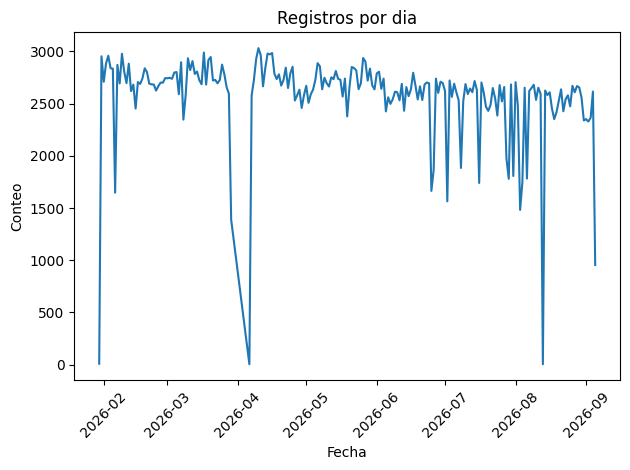

In [7]:
by_day = df.groupby(df['time_index_colombia'].dt.date).size()
fig, ax = plt.subplots()
ax.plot(by_day.index, by_day.values)
ax.set_xlabel('Fecha')
ax.set_ylabel('Conteo')
ax.set_title('Registros por dia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Celda B — Registros por hora del día**

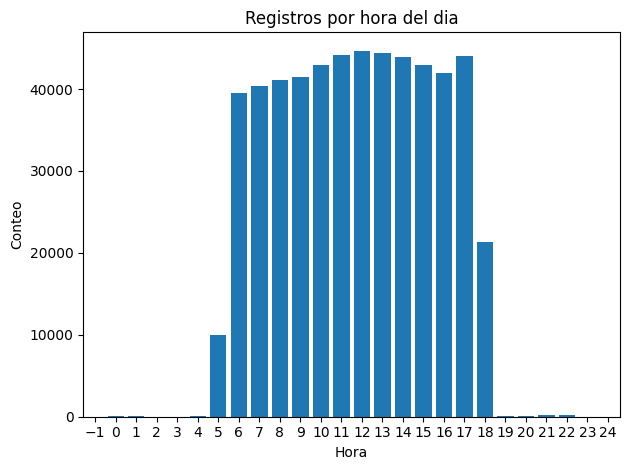

In [8]:
by_hour = df.groupby(df['time_index_colombia'].dt.hour).size()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values)
ax.set_xlabel('Hora')
ax.set_ylabel('Conteo')
ax.set_title('Registros por hora del dia')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

**Celda C — Registros por entity_id**

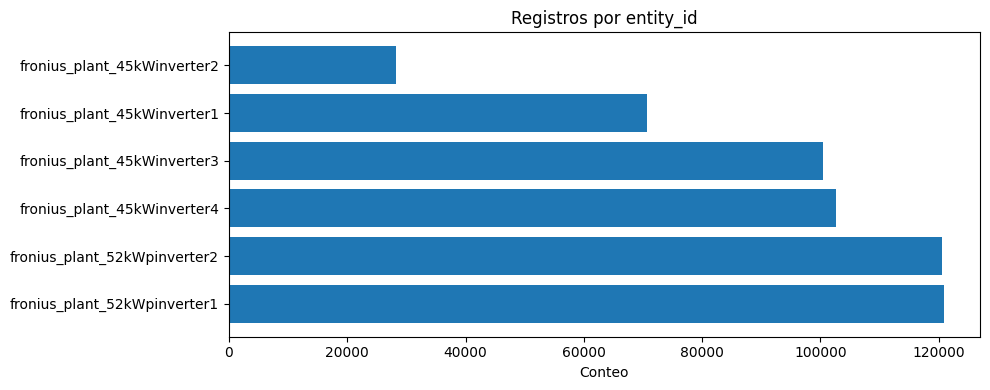

In [9]:
by_entity = df['entity_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(by_entity) * 0.3)))
ax.barh(by_entity.index.astype(str), by_entity.values)
ax.set_xlabel('Conteo')
ax.set_title('Registros por entity_id')
plt.tight_layout()
plt.show()

### 3.3 — Distribución de `energyproducedtoday`

**energyproducedtoday — histograma**

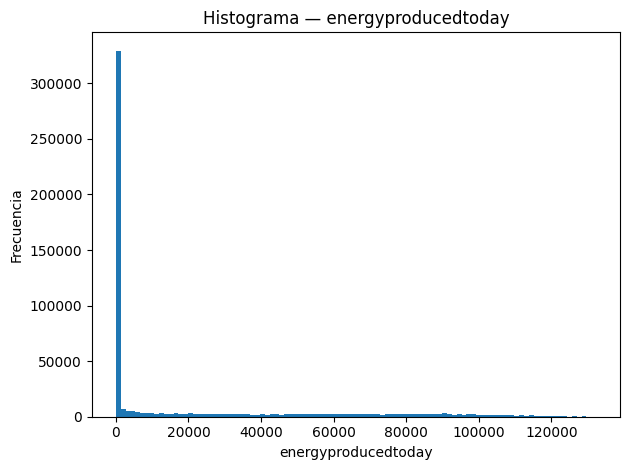

In [10]:
fig, ax = plt.subplots()
ax.hist(df['energyproducedtoday'].dropna(), bins=100)
ax.set_xlabel('energyproducedtoday')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — energyproducedtoday')
plt.tight_layout()
plt.show()

**energyproducedtoday — boxplot**

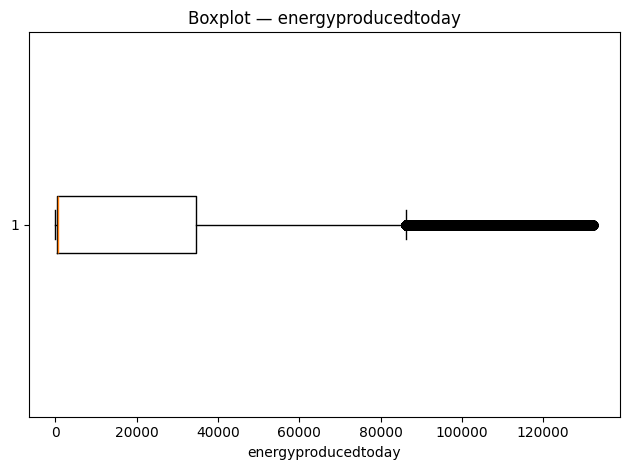

In [11]:
fig, ax = plt.subplots()
ax.boxplot(df['energyproducedtoday'].dropna(), vert=False)
ax.set_xlabel('energyproducedtoday')
ax.set_title('Boxplot — energyproducedtoday')
plt.tight_layout()
plt.show()

### 3.4 — Evidencia del reinicio diario del contador

Esta gráfica es la que justifica todo el Bloque 5. El contador **no es acumulado de por
vida**: dibuja un diente de sierra, sube durante las horas de sol y vuelve a cero en el
siguiente ciclo.

De ahí salen las dos reglas del resample:

- **No se promedia.** La media de un contador no representa ninguna magnitud física.
- **Un delta negativo no se anula.** Ocurre una vez por ciclo y es esperado; la energía de
  esa hora es lo acumulado desde el reinicio, es decir el valor actual del contador.

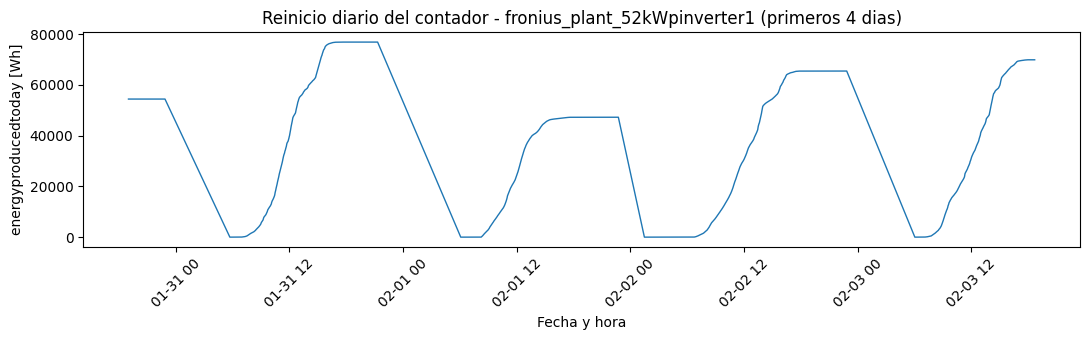

Reinicios detectados por entidad:
entity_id
fronius_plant_45kWinverter1      10
fronius_plant_45kWinverter3      31
fronius_plant_45kWinverter4      27
fronius_plant_52kWpinverter1    211
fronius_plant_52kWpinverter2    212
dtype: int64


In [12]:
## Se toma la entidad con más registros y sus primeros días, que es donde
## el patrón se ve sin necesidad de hacer zoom.
ENT = df['entity_id'].value_counts().idxmax()
muestra = df[df['entity_id'] == ENT].sort_values('time_index_colombia')
ini = muestra['time_index_colombia'].min()
vent = muestra[muestra['time_index_colombia'] < ini + pd.Timedelta(days=4)]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(vent['time_index_colombia'], vent['energyproducedtoday'], lw=1)
ax.set_xlabel('Fecha y hora')
ax.set_ylabel('energyproducedtoday [Wh]')
ax.set_title(f'Reinicio diario del contador - {ENT} (primeros 4 dias)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conteo de reinicios: cuántas veces baja el contador en cada entidad.
_ord = df.sort_values(['entity_id', 'time_index_colombia'])
_neg = _ord.groupby('entity_id', observed=True)['energyproducedtoday'].diff() < 0
print('Reinicios detectados por entidad:')
print(_ord[_neg].groupby('entity_id', observed=True).size())

## Bloque 4 — Limpieza de atípicos

### 4.1 — Conversión a numéricos

In [13]:
# Se repite la conversión del Bloque 2 para poder correr la limpieza sola,
# sin tener que volver a ejecutar todo el notebook desde el inicio
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 4.2 — Validación de rangos físicos

In [14]:
print('NaNs antes:')
print(df[num_cols].isna().sum())

## Energía producida en el día por UN inversor, en Wh. El tope de 200.000 Wh
## (200 kWh) se fija sobre la placa del equipo más grande de las dos plantas:
## el Fronius Symo 24.0-3 son 24 kW, que ni en el mejor día tropical entrega
## más de ~170 kWh. El máximo real observado en la serie es 132.310 Wh, así que
## el filtro no toca ningún dato válido y sí atrapa los centinelas de desborde
## de entero (2**31, 2**32) que ya aparecieron en energyproducedlifetime.
RANGES = {
    'energyproducedtoday': (0, 200_000),
}

## Lo que queda fuera de rango no se borra aquí: se marca como NaN.
## La fila completa recién se elimina en el 4.3.
for col, (lo, hi) in RANGES.items():
    df[col] = df[col].where(df[col].between(lo, hi))

print('NaNs despues:')
print(df[num_cols].isna().sum())

NaNs antes:
energyproducedtoday    0
dtype: int64
NaNs despues:
energyproducedtoday    0
dtype: int64


### 4.3 — Eliminación de filas sin información esencial

In [15]:
## Cae la fila entera si le falta cualquier columna: tanto los vacíos que ya venían
## del origen como los valores que quedaron fuera de rango en el 4.2
before = len(df)
df.dropna(inplace=True)
print(f'Filas eliminadas: {before - len(df)}  — shape resultante: {df.shape}')

Filas eliminadas: 0  — shape resultante: (543480, 4)


## Bloque 5 — Resample horario: energía incremental con regla de reinicio diario

`energyproducedtoday` es un contador **diario**, así que el Bloque 5 no promedia: toma el
último valor de cada hora y calcula la energía de esa hora a partir de la diferencia con
la hora anterior.

- **5.1** — valor del contador al **cierre de cada hora** (`last`) + nº de muestras crudas (`n_muestras`).
- **5.2** — **energía horaria** con la regla del reinicio + banderas de calidad (`gap_h`, `calidad`).
- **5.3** — validación contra el total diario del propio contador.

In [16]:
## Este FREQ nos permite cambiar la frecuencia de resampleo de
## los datos, dependiendo de lo que requieran los Indicadores o KPIs
FREQ = '60min'

## Tolerancia de hueco: con FREQ='60min', dos horas contiguas están a 1 h de distancia.
## Si se cambia el FREQ hay que ajustar este umbral en la misma unidad (horas).
GAP_MAX_H = 1   # horas contiguas = 'ok'; un salto mayor marca 'hueco'

# 5.1 — Contador al cierre de cada hora ('last', NO 'mean') y cobertura cruda por hora
## Se usa 'last' porque la variable es un contador: el promedio de un acumulado no
## representa nada físico, pero su último valor sí es el estado del inversor al
## cerrar la hora.
grp = df.set_index('time_index_colombia').groupby('entity_id', observed=True).resample(FREQ)
hourly = grp[num_cols].last()
hourly['n_muestras'] = grp.size()            # nº de lecturas crudas que cayeron en la hora
hourly = hourly.reset_index()

## El resample crea intervalos vacíos donde el inversor no reportó nada.
## Aquí se descartan: n_muestras == 0 significa hora sin ninguna lectura cruda.
# Solo horas con dato real (no se fabrican horas vacías)
hourly = hourly[hourly['n_muestras'] > 0].copy()

## refplant es un atributo de la entidad, no de la hora: el resample lo pierde,
## así que se vuelve a pegar desde la tabla cruda.
planta = df.groupby('entity_id', observed=True)['refplant'].first()
hourly['refplant'] = hourly['entity_id'].map(planta).astype('category')

print('Horas con dato por entidad:')
print(hourly.groupby('entity_id', observed=True).size())

Horas con dato por entidad:
entity_id
fronius_plant_45kWinverter1     2578
fronius_plant_45kWinverter2     1128
fronius_plant_45kWinverter3     2788
fronius_plant_45kWinverter4     2787
fronius_plant_52kWpinverter1    3359
fronius_plant_52kWpinverter2    3027
dtype: int64


In [17]:
# 5.2 — Energía por hora, con la regla del reinicio diario
## Se ordena por entidad y tiempo porque el diff() de abajo depende del orden de las filas;
## el groupby evita que la energía de un inversor se calcule contra la de otro.
df_h = hourly.sort_values(['entity_id', 'time_index_colombia']).copy()
gb = df_h.groupby('entity_id', observed=True)

# Separación (en horas) respecto a la hora-con-dato previa; 1.0 = contigua
df_h['gap_h'] = gb['time_index_colombia'].diff().dt.total_seconds() / 3600

for c in num_cols:
    d = gb[c].diff()

    ## AQUÍ está la diferencia con el notebook del XW. Como el contador es diario,
    ## que baje no es corrupción: es el reinicio del ciclo. En esa hora la energía
    ## producida es lo que el contador lleva acumulado desde que se reinició, o sea
    ## su valor actual. Anular el dato (como hace el XW con sus acumulados de por
    ## vida) borraría producción real.
    df_h['reinicio'] = d < 0
    df_h[c + '_delta'] = np.where(df_h['reinicio'], df_h[c], d)

# Banderas de calidad. No se borra ninguna fila: se marca, y quien calcule el
# indicador decide si la usa.
##   inicio -> primera hora de la entidad, no hay delta calculable
##   hueco  -> la energía atraviesa un vacío: la suma del período sigue siendo correcta,
##             pero esa hora no representa una hora real y no sirve para perfiles horarios
##   ok     -> hora contigua a la anterior
##
## `reinicio` va como columna aparte y no como un cuarto valor de `calidad` porque casi
## todos los reinicios caen de madrugada, cuando el inversor lleva horas sin reportar:
## si compartieran columna, el 'hueco' taparía al 'reinicio' y la bandera no serviría
## de nada. Así además `calidad` conserva los mismos tres valores que el notebook del XW.
df_h['calidad'] = np.where(df_h['gap_h'] <= GAP_MAX_H, 'ok', 'hueco')
df_h.loc[df_h['gap_h'].isna(), 'calidad'] = 'inicio'   # 1ª hora de cada entidad: sin delta

## Se exportan las energías horarias (no los acumulados) más las columnas de calidad,
## que es lo que consumen IND-08, KPI 06 y KPI 07.
out_cols = (['entity_id', 'refplant', 'time_index_colombia']
            + [c + '_delta' for c in num_cols]
            + ['n_muestras', 'gap_h', 'calidad', 'reinicio'])
df_resampled = df_h[out_cols]

# Se descartan las filas 'inicio' (delta no calculable)
df_resampled = df_resampled[df_resampled['calidad'] != 'inicio'].reset_index(drop=True)

print('shape:', df_resampled.shape)
print()
print('Distribución de calidad:')
print(df_resampled['calidad'].value_counts())
print()
print('Horas marcadas como reinicio del contador:', int(df_resampled['reinicio'].sum()))
print('% de horas cuya energía atraviesa un hueco:',
      round(100 * (df_resampled['calidad'] == 'hueco').mean(), 1), '%')

shape: (15661, 8)

Distribución de calidad:
calidad
ok       14053
hueco     1608
Name: count, dtype: int64

Horas marcadas como reinicio del contador: 457
% de horas cuya energía atraviesa un hueco: 10.3 %


### 5.3 — Validación: suma horaria contra el total diario del contador

Prueba independiente de que la regla del reinicio reconstruye bien la energía. Si el
método es correcto, **sumar las energías horarias de un día tiene que dar el mismo total
que el máximo que alcanzó el contador ese día**, porque el contador es justamente el
acumulado del día.

Las discrepancias que queden señalan días con reinicios a mitad de jornada (el inversor
se reinició y el contador arrancó de nuevo): ahí la suma horaria es *más* correcta que el
máximo, porque recoge los dos tramos y el máximo solo el mayor de ellos.

In [18]:
val = df_resampled.copy()
val['fecha'] = val['time_index_colombia'].dt.date
suma_horaria = val.groupby(['entity_id', 'fecha'], observed=True)['energyproducedtoday_delta'].sum()

crudo = df.copy()
crudo['fecha'] = crudo['time_index_colombia'].dt.date
max_contador = crudo.groupby(['entity_id', 'fecha'], observed=True)['energyproducedtoday'].max()

comp = pd.DataFrame({'suma_horaria': suma_horaria, 'max_contador': max_contador}).dropna()
comp = comp[comp['max_contador'] > 0]
comp['dif_pct'] = (comp['suma_horaria'] - comp['max_contador']) / comp['max_contador'] * 100

## El resultado se reporta POR ENTIDAD y no como un solo número agregado. La razón es
## que un promedio de todas las entidades no significa nada aquí: hay inversores cuyo
## contador está congelado en un valor distinto de cero y nunca se reinicia. En ellos
## la suma horaria da 0 y el máximo del día da el valor congelado, así que la diferencia
## sale -100% sin que la regla del reinicio tenga nada que ver. Mezclarlos con los
## inversores sanos hundiría el indicador y haría parecer roto un método que no lo está.
resumen = comp.groupby(level=0, observed=True).agg(
    dias=('dif_pct', 'size'),
    coincide_1pct=('dif_pct', lambda s: round((s.abs() < 1).mean() * 100, 1)),
    produccion_media_Wh_dia=('max_contador', lambda s: round(s.mean(), 1)),
)
print(resumen.to_string())
print()
print('Cómo leerlo: donde hay producción real y el contador recorre su ciclo completo,')
print('la coincidencia debe ser alta (>95%). Donde la producción media diaria es de unos')
print('pocos cientos de Wh, el contador está congelado, no se reinicia nunca y la')
print('comparación simplemente no aplica: esa fila habla del estado del inversor,')
print('no de la calidad de la limpieza.')

                              dias  coincide_1pct  produccion_media_Wh_dia
entity_id                                                                 
fronius_plant_45kWinverter1    203            3.4                    228.0
fronius_plant_45kWinverter2    101            0.0                     66.0
fronius_plant_45kWinverter3    208            6.7                   2002.9
fronius_plant_45kWinverter4    208            7.7                   2365.4
fronius_plant_52kWpinverter1   211           98.1                  86172.4
fronius_plant_52kWpinverter2   209           97.6                  92704.4

Cómo leerlo: donde hay producción real y el contador recorre su ciclo completo,
la coincidencia debe ser alta (>95%). Donde la producción media diaria es de unos
pocos cientos de Wh, el contador está congelado, no se reinicia nunca y la
comparación simplemente no aplica: esa fila habla del estado del inversor,
no de la calidad de la limpieza.


## Bloque 6 — Exportación

In [19]:
csv_path     = 'clean_etfroniusinverter.csv'
parquet_path = 'clean_etfroniusinverter.parquet'

df_resampled.to_csv(csv_path, index=False)
df_resampled.to_parquet(parquet_path, engine='pyarrow', index=False)

print(f'CSV guardado en:     {csv_path}  — shape: {df_resampled.shape}')
print(f'Parquet guardado en: {parquet_path}  — shape: {df_resampled.shape}')
print()
print('Columnas:', list(df_resampled.columns))
print()
print('Rango temporal:', df_resampled['time_index_colombia'].min(),
      '->', df_resampled['time_index_colombia'].max())

CSV guardado en:     clean_etfroniusinverter.csv  — shape: (15661, 8)
Parquet guardado en: clean_etfroniusinverter.parquet  — shape: (15661, 8)

Columnas: ['entity_id', 'refplant', 'time_index_colombia', 'energyproducedtoday_delta', 'n_muestras', 'gap_h', 'calidad', 'reinicio']

Rango temporal: 2026-01-30 21:00:00 -> 2026-09-05 10:00:00
